In [ ]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df =sns.load_dataset("titanic")

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.describe(include='object')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


because of frequency we got the count in here histogram plot

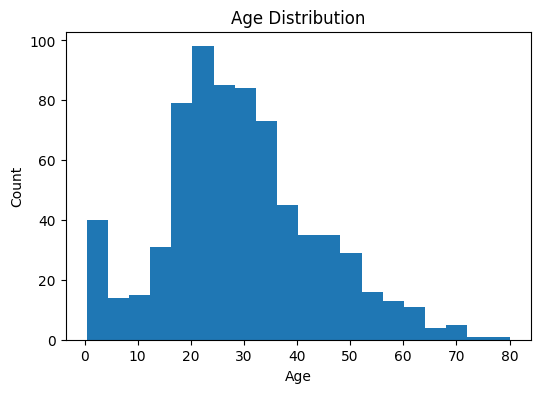

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["age"].dropna(), bins=20)
plt.title('Age Distribution')
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

used for outliners detction in a single feature

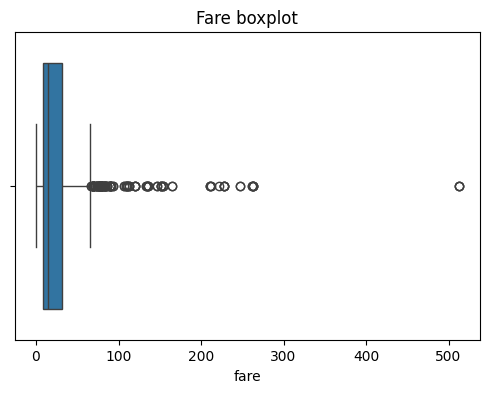

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["fare"])
plt.title("Fare boxplot")

plt.show()

don't uses the number to show the graph for catgeriocal data itself calculates for them

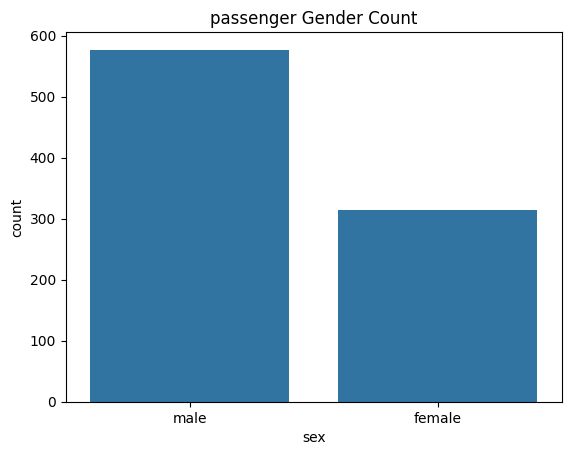

In [ ]:
sns.countplot(x="sex",data=df)

plt.title("passenger Gender Count")

plt.show()

shows relatioonship betwwen two different features called bivaraint graph

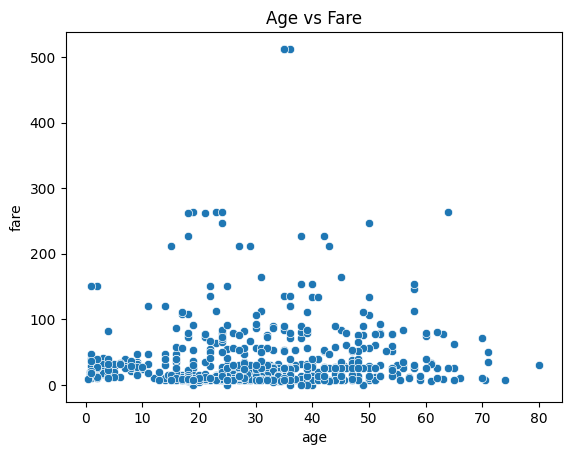

In [ ]:
sns.scatterplot(x="age", y="fare",data=df)

plt.title("Age vs Fare")

plt.show()

shows the trend between the two features

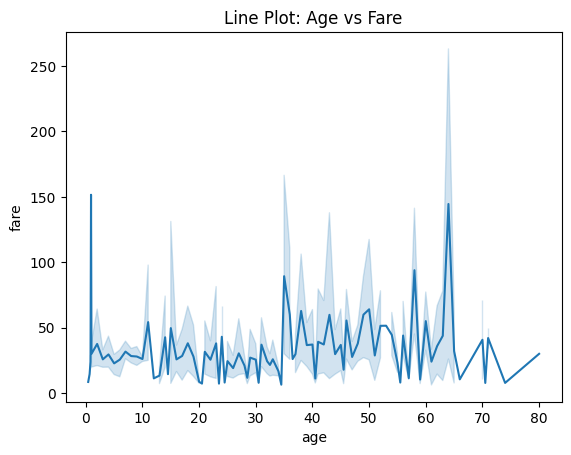

In [ ]:
sns.lineplot(x="age", y="fare",data=df)

plt.title("Line Plot: Age vs Fare")

plt.show()

violinplot is used to show the distrbution by using the boxplot in it by using the two feature which are corelated in reallife

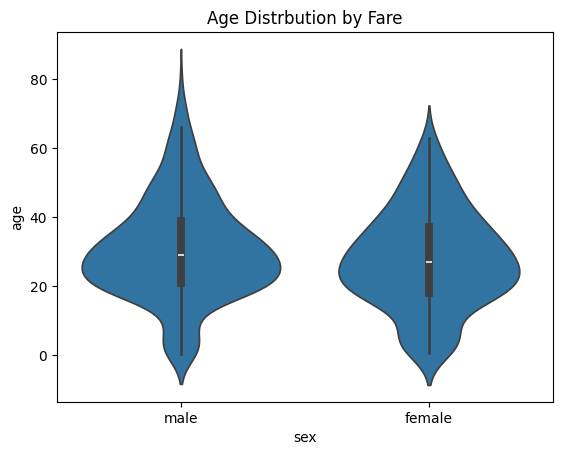

In [ ]:
sns.violinplot(x="sex", y="age",data=df)

plt.title("Age Distrbution by Fare")

plt.show()

correlation heatmap

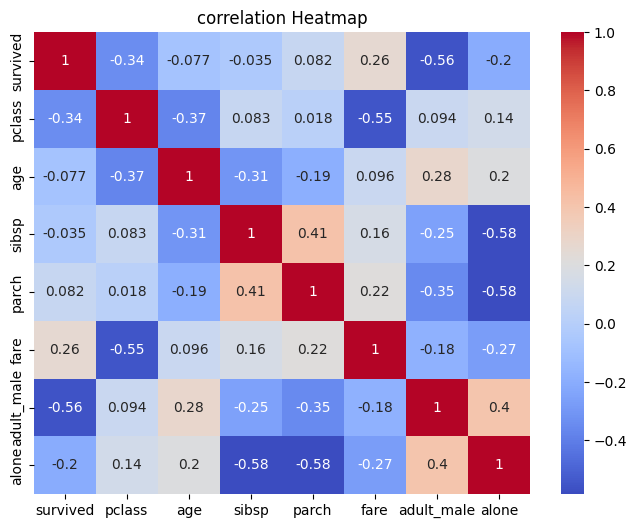

In [ ]:
plt.figure(figsize=(8,6))

corr=df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("correlation Heatmap")

plt.show()

outliner detction:-if the value it is lower than lower bound or upper than upper bound is konwn as outliners if one pf them is true


q1:-25%
q2:-50%
q3:-75%



upperhalf=q3=lowest value after value




lowerhalf=q1=highest value before value


IQR=q3-q1

lowerbound:q1-1.5*IQR


upperbound:q3+1.5*IQR

In [ ]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers =df[(df["fare"] < lower) | (df["fare"] > upper)]

print("number of OUtliers:",len(outliers))

number of OUtliers: 116


detcting the pattterns and trends

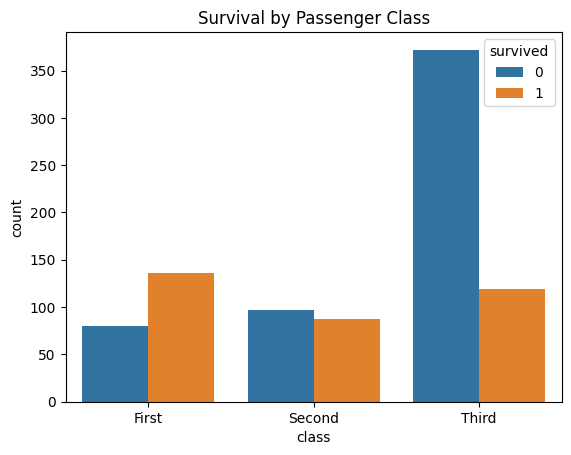

In [ ]:
#bi variant
sns.countplot(x="class", hue="survived",data=df)

plt.title("Survival by Passenger Class")

plt.show()